In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

plt.style.use('fivethirtyeight')

In [3]:
def load_stock_data(file):
    df = pd.read_excel(file)
    df['Date'] = pd.to_datetime(df['Date'])
    df.set_index('Date', inplace=True)
    return df

In [4]:
def prepare_data(df, forecast_days=30):
    df = df[['Close*']].copy()
    df['Prediction'] = df[['Close*']].shift(-forecast_days)
    X = np.array(df.drop('Prediction', axis=1))[:-forecast_days]
    y = np.array(df['Prediction'])[:-forecast_days]

    return X, y, df

In [5]:
def train_and_predict(X, y, df, forecast_days=30):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = LinearRegression()
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)

    mse = mean_squared_error(y_test, prediction)
    r2 = r2_score(y_test, prediction)
    print('Model evaluation')
    print(f'MSE: {mse:.2f}')
    print(f"R2: {r2:.4f}")

    X_future = np.array(df.drop(['Prediction'], axis=1))[-forecast_days:]
    future_prediction = model.predict(X_future)

    return future_prediction, model

In [15]:
def plot_predictions(df, future_days, future_prediction):
    df_future = df.copy()

    last_date = df.index[0]
    future_dates = pd.date_range(last_date + pd.Timedelta(days=1), periods=future_days)
    print(future_dates)

    plt.figure(figsize=(12, 6))
    plt.plot(df.index, df['Close*'], color='tab:blue', linewidth=1.8, label='Historical Close Price')
    plt.scatter([last_date], [df['Close*'].iloc[-1]], color='tab:blue', s=30, zorder=3)
    plt.plot(future_dates, future_prediction, color='tab:orange', linestyle='--', linewidth=2,
             label='Predicted Future Price', zorder=2)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.title('Stock Price Prediction')
    plt.legend()
    plt.show()

In [16]:
forecast_days = 300
stock_data = load_stock_data('yahoo_data.xlsx')
print(stock_data)

                Open      High       Low    Close*  Adj Close**     Volume
Date                                                                      
2023-04-28  33797.43  34104.56  33728.40  34098.16     34098.16  354310000
2023-04-27  33381.66  33859.75  33374.65  33826.16     33826.16  343240000
2023-04-26  33596.34  33645.83  33235.85  33301.87     33301.87  321170000
2023-04-25  33828.34  33875.49  33525.39  33530.83     33530.83  297880000
2023-04-24  33805.04  33891.15  33726.09  33875.40     33875.40  252020000
...              ...       ...       ...       ...          ...        ...
2018-05-07  24317.66  24479.45  24263.42  24357.32     24357.32  307670000
2018-05-04  23865.22  24333.35  23778.87  24262.51     24262.51  329480000
2018-05-03  23836.23  23996.15  23531.31  23930.15     23930.15  389240000
2018-05-02  24097.63  24185.52  23886.30  23924.98     23924.98  385350000
2018-05-01  24117.29  24117.29  23808.19  24099.05     24099.05  380070000

[1258 rows x 6 columns]


In [17]:
stock_data.columns

Index(['Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume'], dtype='object')

Model evaluation
MSE: 12923273.32
R2: 0.1585
DatetimeIndex(['2023-04-29', '2023-04-30', '2023-05-01', '2023-05-02',
               '2023-05-03', '2023-05-04', '2023-05-05', '2023-05-06',
               '2023-05-07', '2023-05-08',
               ...
               '2024-02-13', '2024-02-14', '2024-02-15', '2024-02-16',
               '2024-02-17', '2024-02-18', '2024-02-19', '2024-02-20',
               '2024-02-21', '2024-02-22'],
              dtype='datetime64[ns]', length=300, freq='D')


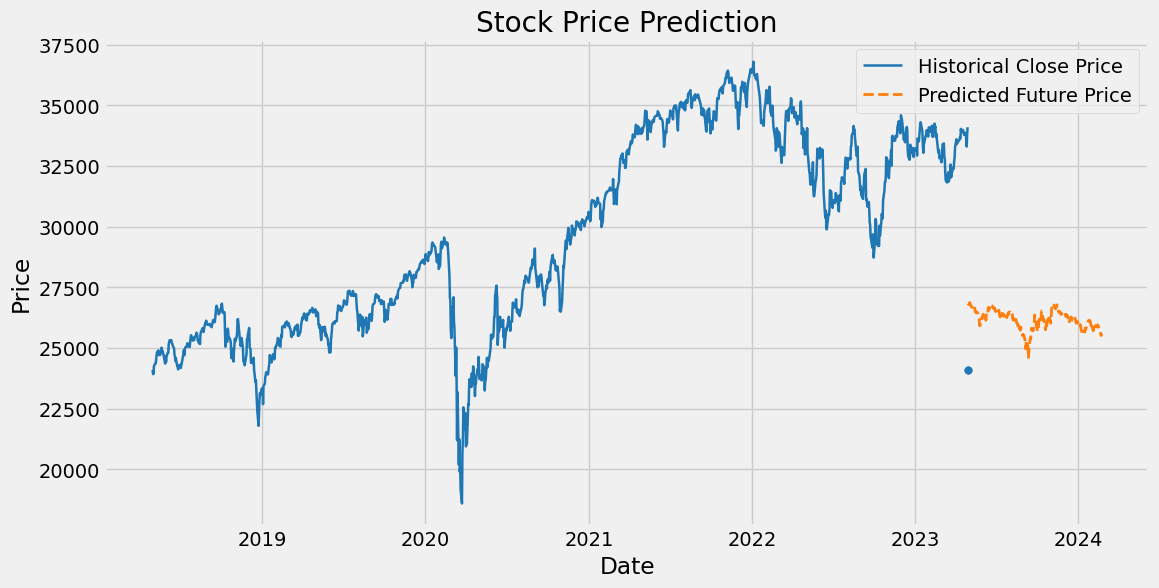

Future Price Predictions:
[26828.08335355 26793.82585517 26803.94099451 26855.7358669
 26875.33199555 26795.25045979 26764.32448192 26711.86419859
 26679.09382666 26683.66685212 26688.75791563 26768.83945139
 26765.0836756  26780.28541259 26669.00994824 26651.83430768
 26494.18550698 26483.94978983 26491.61318016 26446.08835439
 26465.59516614 26471.92326876 26436.75920381 26319.18243192
 26238.31044155 26145.69327837 25916.86337135 25914.74656073
 26073.2126111  26053.7995821  26152.655531   26258.90691952
 26216.38314172 26344.1688357  26389.14882835 26300.97964696
 26338.53740493 26382.60636516 26286.74253253 26234.95212598
 26142.48233568 26418.1946854  26367.2795845  26429.34143497
 26428.34108565 26639.74973062 26669.43420353 26581.38559997
 26636.02521574 26708.71577774 26691.5133421  26686.57411733
 26650.28912525 26710.56463764 26737.06496294 26672.15836909
 26693.81325237 26644.68895539 26646.08229909 26615.76367616
 26628.05814794 26507.81526647 26514.11657402 26511.17804789

In [18]:
X, y, df = prepare_data(stock_data, forecast_days)
future_prediction, model = train_and_predict(X, y, df, forecast_days)
plot_predictions(df, forecast_days, future_prediction)
print('Future Price Predictions:')
print(future_prediction)

In [32]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

TICKER = "BBCA.JK"
START = "2024-07-01"
END = "2026-07-22"
PIVOT_WINDOW = 5      # bar kiri/kanan untuk konfirmasi swing point
K_RANGE = range(2, 16)

In [33]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.dropna()

print(f"Data: {len(df)} bar, {df.index[0].date()} s/d {df.index[-1].date()}")
df.tail()

Data: 494 bar, 2024-07-01 s/d 2026-07-21


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-07-15,6125.0,6125.0,6200.0,6075.0,6125.0,140824900
2026-07-16,6225.0,6225.0,6225.0,6100.0,6125.0,94235100
2026-07-17,6475.0,6475.0,6500.0,6200.0,6225.0,314564200
2026-07-20,6475.0,6475.0,6625.0,6475.0,6525.0,298183300
2026-07-21,6525.0,6525.0,6550.0,6425.0,6550.0,146064700


In [34]:
def find_pivots(df, w=PIVOT_WINDOW):
    high, low = df["High"], df["Low"]
    roll_max = high.rolling(2 * w + 1, center=True).max()
    roll_min = low.rolling(2 * w + 1, center=True).min()

    pivot_high = df.index[(high == roll_max) & roll_max.notna()]
    pivot_low = df.index[(low == roll_min) & roll_min.notna()]

    points = pd.concat([
        pd.DataFrame({"date": pivot_high, "price": high[pivot_high].values, "type": "high"}),
        pd.DataFrame({"date": pivot_low, "price": low[pivot_low].values, "type": "low"}),
    ], ignore_index=True)
    return points.sort_values("date").reset_index(drop=True)


points = find_pivots(df)
print(f"Swing points terdeteksi: {len(points)}")
points.head(10)

Swing points terdeteksi: 80


,date,price,type
0,2024-07-10,10225.0,high
1,2024-07-17,9800.0,low
2,2024-07-18,9800.0,low
3,2024-07-29,10425.0,high
4,2024-08-05,9875.0,low
5,2024-08-21,10500.0,high
6,2024-08-29,10500.0,high
7,2024-09-04,10125.0,low
8,2024-09-23,10950.0,high
9,2024-09-24,10950.0,high


In [35]:
def evaluate_k(prices, k_range=K_RANGE):
    """Hitung inertia (elbow) dan silhouette untuk tiap k."""
    X = prices.reshape(-1, 1)
    rows = []
    for k in k_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, km.labels_) if k >= 2 else np.nan,
        })
    return pd.DataFrame(rows).set_index("k")


def elbow_k(inertia: pd.Series) -> int:
    """Deteksi siku dengan metode kneedle (jarak tegak lurus terjauh ke garis ujung-ke-ujung)."""
    k = inertia.index.values.astype(float)
    y = inertia.values.astype(float)

    # normalisasi ke [0,1] agar sumbu k dan inertia sebanding
    kn = (k - k.min()) / (k.max() - k.min())
    yn = (y - y.min()) / (y.max() - y.min())

    # garis lurus dari titik pertama ke titik terakhir kurva
    x1, y1, x2, y2 = kn[0], yn[0], kn[-1], yn[-1]
    dist = np.abs((y2 - y1) * kn - (x2 - x1) * yn + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
    return int(k[dist.argmax()])


evalu = evaluate_k(points["price"].values)
k_elbow = elbow_k(evalu["inertia"])
k_silhouette = int(evalu["silhouette"].idxmax())

print(f"k dari elbow method : {k_elbow}")
print(f"k dari silhouette   : {k_silhouette}")
evalu.assign(inertia=lambda d: d["inertia"].map("{:,.0f}".format),
             silhouette=lambda d: d["silhouette"].round(3))

k dari elbow method : 4
k dari silhouette   : 15


,inertia,silhouette
k,,
2,"56,966,312",0.551
3,"20,719,365",0.619
4,"12,535,117",0.591
5,"8,698,606",0.560
6,"5,927,728",0.567
7,"3,812,890",0.586
8,"3,061,183",0.607
9,"2,421,264",0.598
10,"1,836,444",0.597


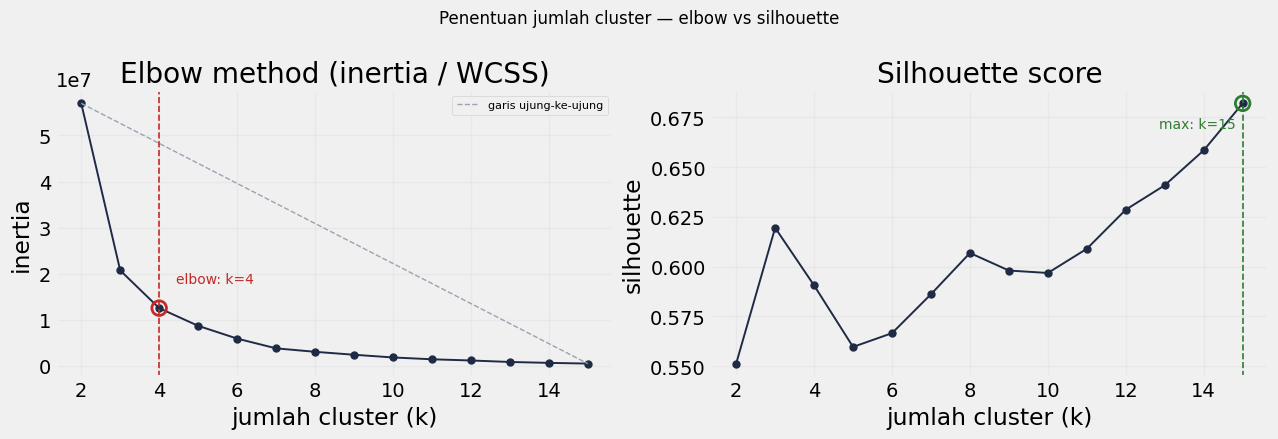

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Elbow ---
ax1.plot(evalu.index, evalu["inertia"], "o-", color="#1f2a44", lw=1.4, ms=5)
ax1.plot([evalu.index[0], evalu.index[-1]],
         [evalu["inertia"].iloc[0], evalu["inertia"].iloc[-1]],
         "--", color="#9aa3b2", lw=1, label="garis ujung-ke-ujung")
ax1.axvline(k_elbow, color="#c62828", ls="--", lw=1.2)
ax1.scatter([k_elbow], [evalu.loc[k_elbow, "inertia"]], s=110, facecolor="none",
            edgecolor="#c62828", lw=2, zorder=3)
ax1.annotate(f"elbow: k={k_elbow}", (k_elbow, evalu.loc[k_elbow, "inertia"]),
             textcoords="offset points", xytext=(12, 18), color="#c62828", fontsize=10)
ax1.set_title("Elbow method (inertia / WCSS)")
ax1.set_xlabel("jumlah cluster (k)"); ax1.set_ylabel("inertia")
ax1.legend(fontsize=8); ax1.grid(alpha=0.2)

# --- Silhouette ---
ax2.plot(evalu.index, evalu["silhouette"], "o-", color="#1f2a44", lw=1.4, ms=5)
ax2.axvline(k_silhouette, color="#2e7d32", ls="--", lw=1.2)
ax2.scatter([k_silhouette], [evalu.loc[k_silhouette, "silhouette"]], s=110, facecolor="none",
            edgecolor="#2e7d32", lw=2, zorder=3)
ax2.annotate(f"max: k={k_silhouette}", (k_silhouette, evalu.loc[k_silhouette, "silhouette"]),
             textcoords="offset points", xytext=(-60, -18), color="#2e7d32", fontsize=10)
ax2.set_title("Silhouette score")
ax2.set_xlabel("jumlah cluster (k)"); ax2.set_ylabel("silhouette")
ax2.grid(alpha=0.2)

fig.suptitle("Penentuan jumlah cluster — elbow vs silhouette", fontsize=12)
fig.tight_layout()
plt.show()

In [37]:
K_METHOD = "elbow"   # "elbow" | "silhouette" | int

if isinstance(K_METHOD, int):
    k = K_METHOD
elif K_METHOD == "silhouette":
    k = k_silhouette
else:
    k = k_elbow

print(f"K dipakai: {k}  (metode: {K_METHOD})")

K dipakai: 4  (metode: elbow)


In [38]:
X = points["price"].values.reshape(-1, 1)
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
points = points.assign(cluster=km.labels_)

levels = (
    points.groupby("cluster")["price"]
    .agg(level="mean", n_touch="size", low="min", high="max")
    .sort_values("level")
    .reset_index(drop=True)
)

last_price = float(df["Close"].iloc[-1])
levels["zona"] = np.where(levels["level"] < last_price, "SUPPORT", "RESISTANCE")
levels["jarak_%"] = (levels["level"] / last_price - 1) * 100

print(f"Harga terakhir: {last_price:,.0f}\n")
levels

Harga terakhir: 6,525



,level,n_touch,low,high,zona,jarak_%
0,6016.250000,12,4820.0,6550.0,SUPPORT,-7.796935
1,7484.375000,16,6825.0,7950.0,RESISTANCE,14.703065
2,8570.000000,25,8100.0,9200.0,RESISTANCE,31.340996
3,10105.555556,27,9525.0,10950.0,RESISTANCE,54.874415


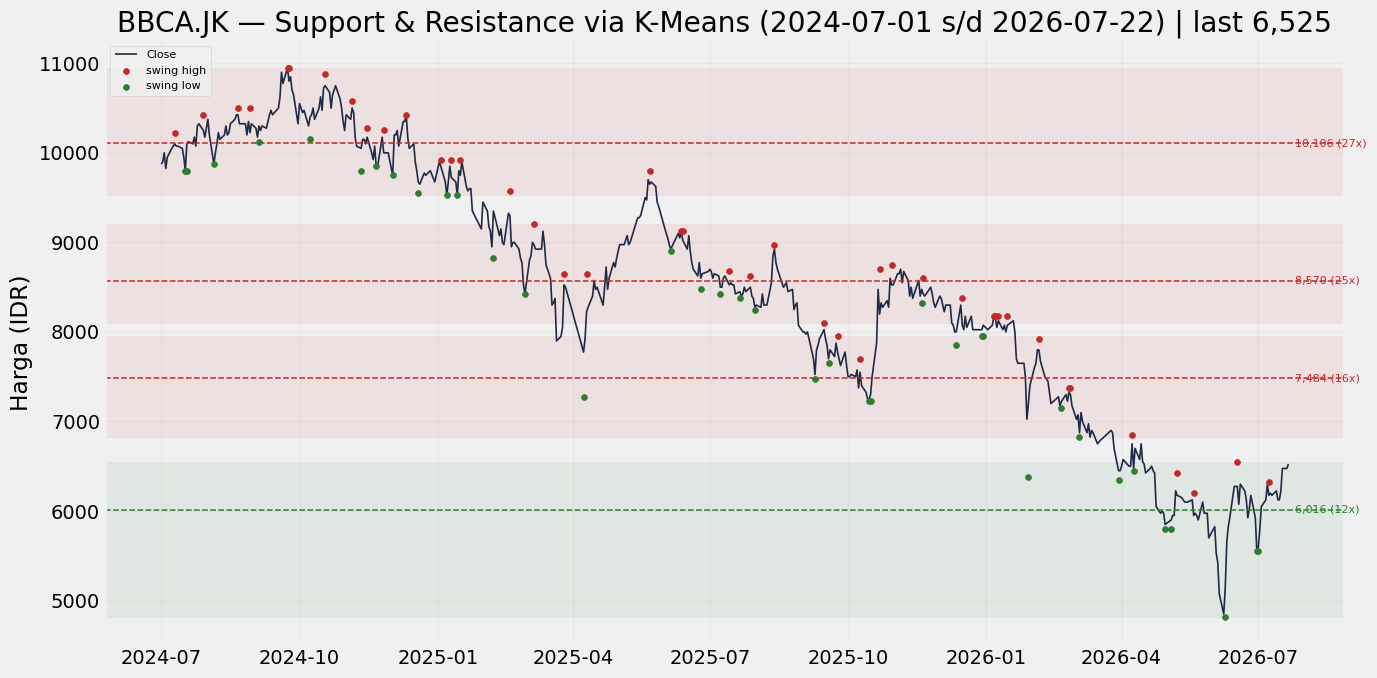

In [39]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df.index, df["Close"], color="#1f2a44", lw=1.2, label="Close")

for _, r in levels.iterrows():
    color = "#2e7d32" if r.zona == "SUPPORT" else "#c62828"
    ax.axhspan(r.low, r.high, color=color, alpha=0.08)
    ax.axhline(r.level, color=color, ls="--", lw=1.1)
    ax.text(df.index[-1], r.level, f"  {r.level:,.0f} ({int(r.n_touch)}x)",
            va="center", fontsize=8, color=color)

hi = points[points.type == "high"]
lo = points[points.type == "low"]
ax.scatter(hi.date, hi.price, s=18, color="#c62828", zorder=3, label="swing high")
ax.scatter(lo.date, lo.price, s=18, color="#2e7d32", zorder=3, label="swing low")

ax.set_title(f"BBCA.JK — Support & Resistance via K-Means "
             f"({START} s/d {END}) | last {last_price:,.0f}")
ax.set_ylabel("Harga (IDR)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

In [ ]:

# Try to import TensorFlow; if unavailable, fall back to a sklearn classifier
USE_TF = True
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception:
    USE_TF = False
    from sklearn.ensemble import RandomForestClassifier

def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


def prepare_sequences(X, y, lookback=LOOKBACK):
    seq_X, seq_y = [], []
    for i in range(len(X) - lookback - FUTURE_DAYS + 1):
        seq_X.append(X[i : i + lookback])
        seq_y.append(y[i + lookback - 1])
    return np.array(seq_X), np.array(seq_y)